# Riskfolio Example 1

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format


Using a time period from **January 2025 to August 2025** to optimize a portfolio for **1 month in the future** (e.g., September 2025) is not ideal. This is because the data you are using is from the **future** relative to the optimization period, which introduces **data leakage** and makes the results unrealistic. In real-world scenarios, you should only use **historical data** up to the current date to make predictions or optimizations for the future.

### What to change:
1. **Use historical data up to the current date**:
    - Replace the `start` and `end` dates with a range that ends at the current date (or the most recent available data).
    - For example:
      ```python
      start = '2023-01-01'  # Example historical start date
      end = '2023-08-31'    # Most recent available data
      ```

2. **Ensure the data reflects realistic conditions**:
    - Avoid using future data for training or optimization.
    - Use only data that would have been available at the time of optimization.

3. **Consider the length of the historical period**:
    - For a 1-month future optimization, a historical period of **6-12 months** is often sufficient to capture recent trends and volatility.

4. **Validate the model**:
    - After optimizing the portfolio, validate its performance using a separate out-of-sample period (e.g., the next month after the historical period).

By making these changes, your portfolio optimization will be more realistic and applicable to real-world scenarios.

In [2]:


# Date range
start = '2023-08-18'
end = '2025-08-18'

# Tickers of assets 
assets = ['AVEM', 'XMMO', 'ESGD', 'BYLD', 'ISCF', 'HYEM', 'VWOB', 'VNQI', 'VNQ', 'SNPE'] # , 'AGEPX', 'SWSSX', 'SWVXX' mutual funds 
assets.sort()
raw_data = yf.download(assets, start = start, end = end, auto_adjust=False)
data = raw_data .loc[:,('Adj Close', slice(None))]
data.columns = assets

[*********************100%***********************]  10 of 10 completed


In [3]:
# get etf categories 

# categories = {}

# for asset in assets:
#     ticker = yf.Ticker(asset)
#     info = ticker.info
#     category = info.get('category', 'Unknown')
#     categories[asset] = category
# categories

In [4]:
# Calculating returns

Y = data[assets].pct_change().dropna()

display(Y.head())

,AVEM,BYLD,ESGD,HYEM,ISCF,SNPE,VNQ,VNQI,VWOB,XMMO
Date,,,,,,,,,,
2023-08-21,0.3228%,-0.3242%,0.3566%,-0.2244%,0.0000%,0.8006%,-0.9199%,-0.7614%,-0.6126%,0.4578%
2023-08-22,-0.0379%,0.0930%,-0.0853%,-0.0562%,0.0496%,-0.1986%,0.2886%,0.3836%,0.2999%,-0.1848%
2023-08-23,1.5906%,0.8774%,1.0955%,0.8436%,0.8756%,1.1689%,1.5764%,1.6561%,1.4615%,0.2344%
2023-08-24,-0.4660%,-0.3176%,-1.3791%,-0.1115%,-1.3429%,-1.4749%,-0.3818%,-0.7770%,-0.4747%,-0.8494%
2023-08-25,0.2060%,0.1154%,0.6279%,-0.2792%,0.6640%,0.6986%,0.0742%,0.4799%,0.3125%,0.8319%


## Estimating Mean Variance Portfolio

In [10]:
import riskfolio as rp

# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimal portfolio

# Select method and estimate input parameters:

method_mu='hist' # Method to estimate expected returns based on historical data.
method_cov='hist' # Method to estimate covariance matrix based on historical data.

port.assets_stats(method_mu=method_mu, method_cov=method_cov)

# Estimate optimal portfolio:

model='Classic' # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
rm = 'MV' # Risk measure used, this time will be variance
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True # Use historical scenarios for risk measures that depend on scenarios
rf = 0 # Risk free rate
l = 0 # Risk aversion factor, only useful when obj is 'Utility'

port.card = None 

# Then we need to set the constraint on the minimum number of effective assets
port.nea = 8

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,AVEM,BYLD,ESGD,HYEM,ISCF,SNPE,VNQ,VNQI,VWOB,XMMO
weights,8.8598%,15.2852%,7.0488%,18.8242%,8.9098%,10.4170%,0.0000%,6.3512%,14.4160%,9.8880%


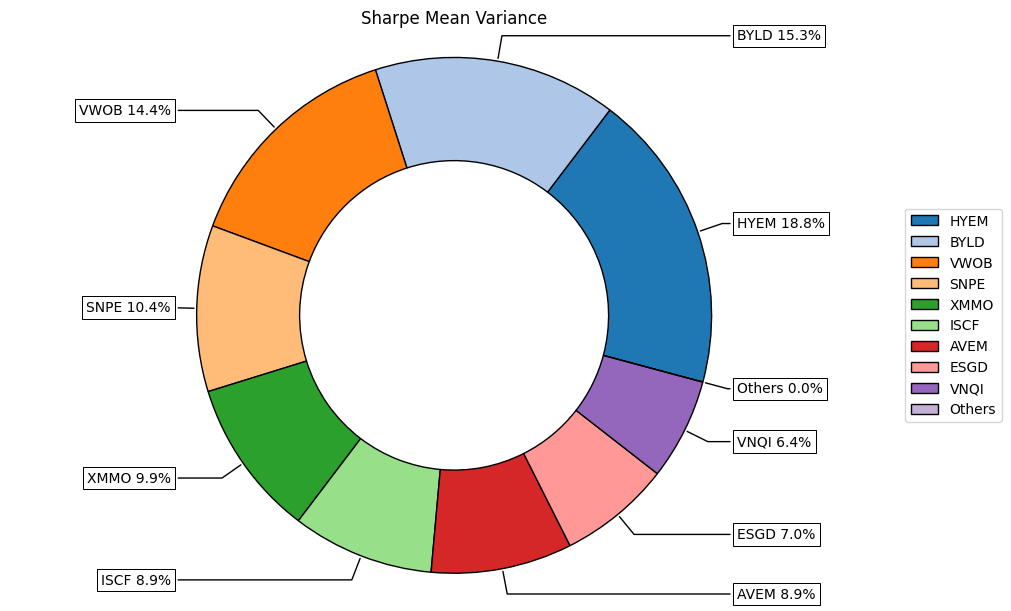

In [11]:
# Plotting the composition of the portfolio

ax = rp.plot_pie(w=w, title='Sharpe Mean Variance', others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)

In [12]:
points = 50 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, points=points, rf=rf, hist=hist)

display(frontier.T.head())

,AVEM,BYLD,ESGD,HYEM,ISCF,SNPE,VNQ,VNQI,VWOB,XMMO
0,7.2413%,18.6438%,7.3620%,17.6960%,7.0123%,7.5837%,6.3509%,8.2862%,15.8471%,3.9767%
1,7.7526%,17.8067%,7.1093%,18.5510%,7.5827%,8.6305%,3.5456%,7.3706%,15.5623%,6.0888%
2,8.0112%,17.2770%,7.0494%,18.7591%,7.8892%,9.0871%,2.4893%,7.0507%,15.3418%,7.0453%
3,8.2276%,16.8019%,7.0247%,18.8539%,8.1485%,9.4460%,1.7285%,6.8306%,15.1321%,7.8062%
4,8.4208%,16.3545%,7.0183%,18.8890%,8.3824%,9.7548%,1.1257%,6.6622%,14.9286%,8.4638%


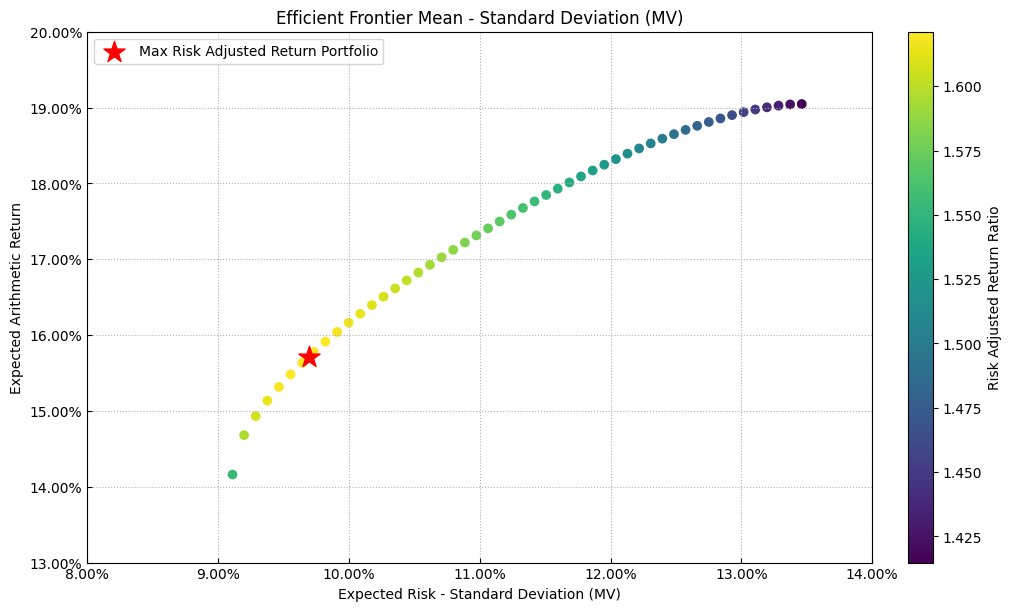

In [13]:
# Plotting the efficient frontier

label = 'Max Risk Adjusted Return Portfolio' # Title of point
mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

ax = rp.plot_frontier(w_frontier=frontier, mu=mu, cov=cov, returns=returns, rm=rm,
                      rf=rf, alpha=0.05, cmap='viridis', w=w, label=label,
                      marker='*', s=16, c='r', height=6, width=10, ax=None)

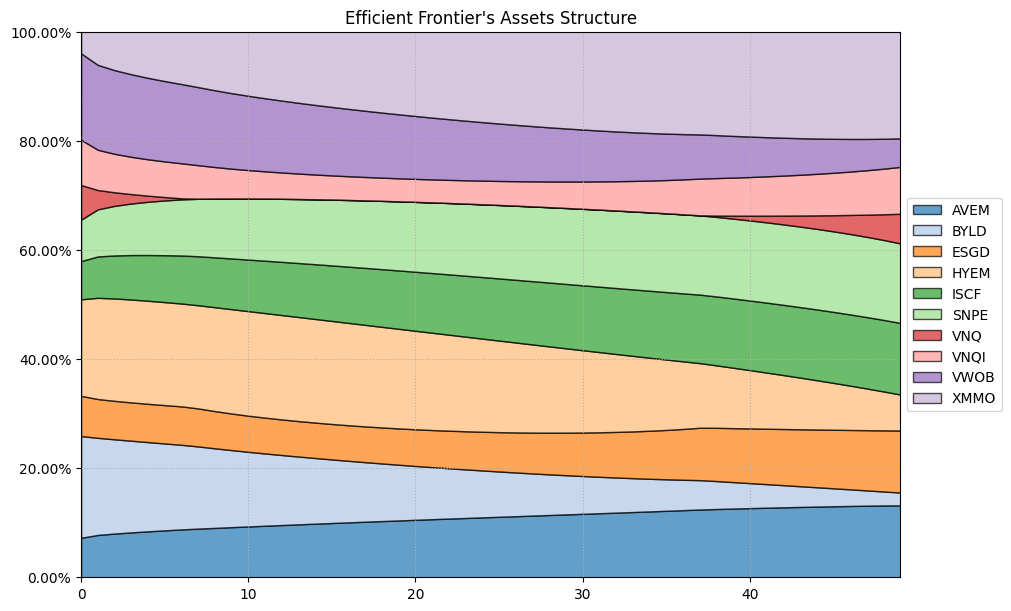

In [14]:
# Plotting efficient frontier composition

ax = rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None)

In [15]:
rm = 'CVaR' # Risk measure
obj= 'Sharpe'

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,AVEM,BYLD,ESGD,HYEM,ISCF,SNPE,VNQ,VNQI,VWOB,XMMO
weights,8.3426%,15.4605%,7.6066%,19.2341%,10.1769%,8.8747%,0.0000%,6.7103%,13.7794%,9.8148%


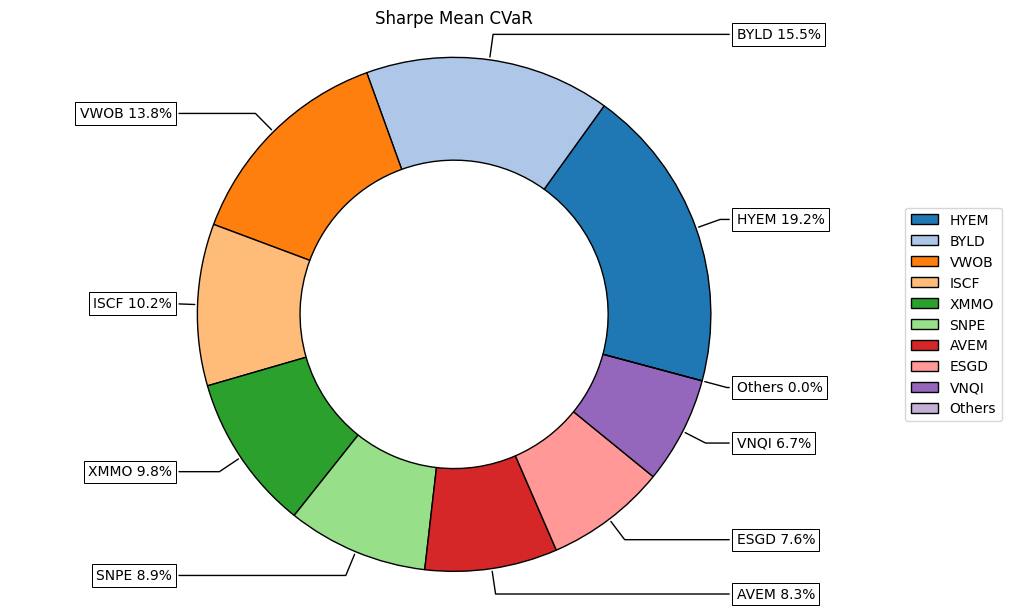

In [16]:
ax = rp.plot_pie(w=w, title='Sharpe Mean CVaR', others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)

In [17]:
points = 50 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, points=points, rf=rf, hist=hist)

display(frontier.T.head())

,AVEM,BYLD,ESGD,HYEM,ISCF,SNPE,VNQ,VNQI,VWOB,XMMO
0,7.5984%,18.4861%,8.3338%,17.5311%,8.1485%,7.2640%,4.3349%,9.4434%,15.2933%,3.5667%
1,7.8261%,17.7203%,7.8084%,18.2224%,8.6632%,7.8789%,2.0136%,8.5890%,15.1326%,6.1455%
2,8.0662%,17.2430%,7.8321%,18.3035%,8.9670%,8.2940%,0.9778%,8.3400%,14.8655%,7.1110%
3,8.1215%,16.6511%,7.9355%,18.5296%,9.5078%,8.5741%,0.3018%,8.1045%,14.5067%,7.7673%
4,8.3118%,16.0913%,7.7876%,18.8533%,9.8469%,8.9069%,0.0000%,7.6098%,14.1666%,8.4257%


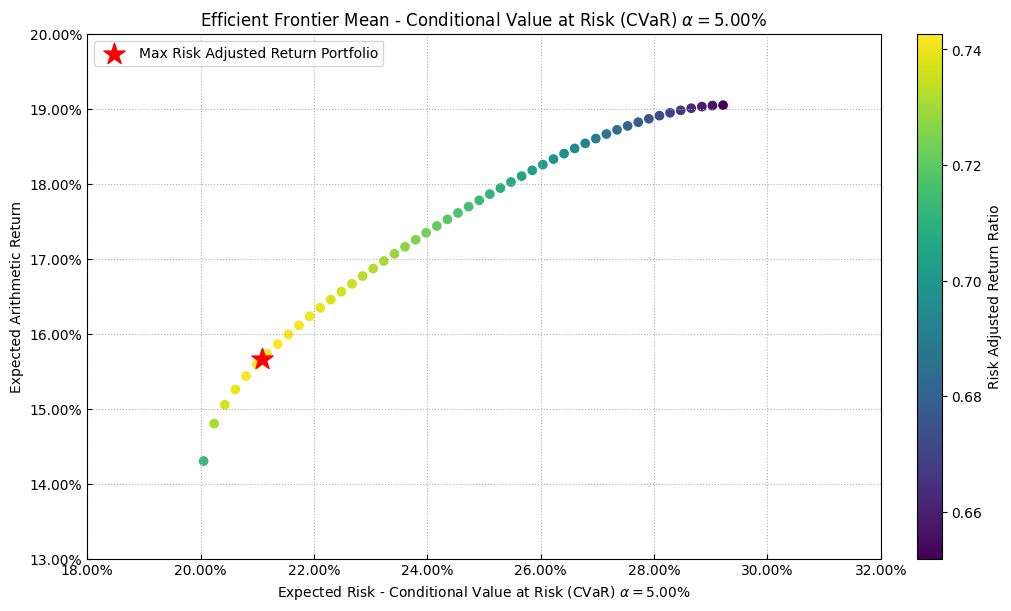

In [18]:
label = 'Max Risk Adjusted Return Portfolio' # Title of point

ax = rp.plot_frontier(w_frontier=frontier, mu=mu, cov=cov, returns=returns, rm=rm,
                      rf=rf, alpha=0.05, cmap='viridis', w=w, label=label,
                      marker='*', s=16, c='r', height=6, width=10, ax=None)

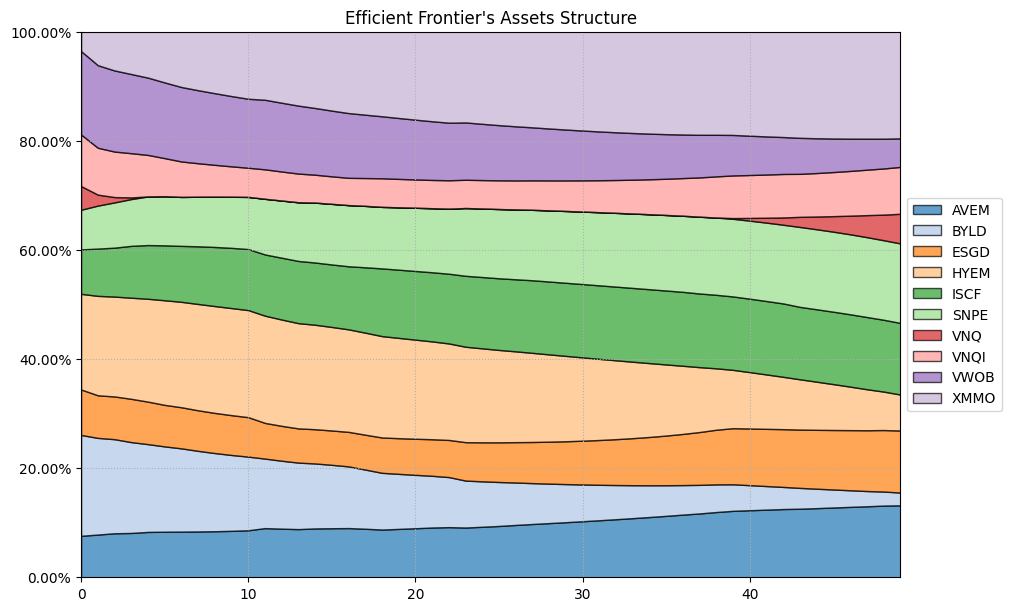

In [19]:
# Plotting efficient frontier composition

ax = rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None)

In [20]:
# Risk Measures available:
#
# 'MV': Standard Deviation.
# 'MAD': Mean Absolute Deviation.
# 'MSV': Semi Standard Deviation.
# 'FLPM': First Lower Partial Moment (Omega Ratio).
# 'SLPM': Second Lower Partial Moment (Sortino Ratio).
# 'CVaR': Conditional Value at Risk.
# 'EVaR': Entropic Value at Risk.
# 'WR': Worst Realization (Minimax)
# 'MDD': Maximum Drawdown of uncompounded cumulative returns (Calmar Ratio).
# 'ADD': Average Drawdown of uncompounded cumulative returns.
# 'CDaR': Conditional Drawdown at Risk of uncompounded cumulative returns.
# 'EDaR': Entropic Drawdown at Risk of uncompounded cumulative returns.
# 'UCI': Ulcer Index of uncompounded cumulative returns.

rms = ['MV', 'MAD', 'MSV', 'FLPM', 'SLPM', 'CVaR',
       'EVaR', 'WR', 'MDD', 'ADD', 'CDaR', 'UCI', 'EDaR']

w_s = pd.DataFrame([])

for i in rms:
    w = port.optimization(model=model, rm=i, obj=obj, rf=rf, l=l, hist=hist)
    w_s = pd.concat([w_s, w], axis=1)
    
w_s.columns = rms

In [21]:
w_s.style.format("{:.2%}").background_gradient(cmap='YlGn')

,MV,MAD,MSV,FLPM,SLPM,CVaR,EVaR,WR,MDD,ADD,CDaR,UCI,EDaR
AVEM,8.86%,8.93%,8.76%,9.06%,8.74%,8.34%,8.52%,8.29%,6.17%,10.15%,10.74%,10.36%,8.92%
BYLD,15.29%,14.83%,15.44%,14.84%,15.50%,15.46%,16.97%,17.04%,16.16%,14.17%,15.04%,14.49%,16.07%
ESGD,7.05%,7.31%,6.79%,7.05%,6.74%,7.61%,3.21%,2.58%,9.57%,8.73%,9.20%,8.98%,9.15%
HYEM,18.82%,19.49%,18.85%,19.48%,18.81%,19.23%,15.21%,14.58%,16.97%,19.90%,19.92%,20.27%,17.61%
ISCF,8.91%,8.47%,8.98%,8.51%,9.01%,10.18%,5.88%,5.07%,12.05%,8.42%,8.89%,8.84%,10.38%
SNPE,10.42%,11.94%,10.40%,11.97%,10.25%,8.87%,8.31%,8.16%,4.78%,12.12%,7.24%,9.79%,5.54%
VNQ,0.00%,0.71%,0.00%,0.66%,0.00%,0.00%,3.79%,5.57%,1.97%,0.65%,0.00%,0.00%,0.23%
VNQI,6.35%,5.49%,6.90%,5.56%,6.99%,6.71%,8.30%,8.23%,8.65%,4.50%,6.63%,5.94%,9.31%
VWOB,14.42%,13.80%,14.37%,13.66%,14.43%,13.78%,17.70%,18.07%,16.54%,12.59%,12.20%,12.13%,15.49%
XMMO,9.89%,9.00%,9.50%,9.22%,9.53%,9.81%,12.11%,12.42%,7.14%,8.77%,10.14%,9.19%,7.31%


<Axes: >

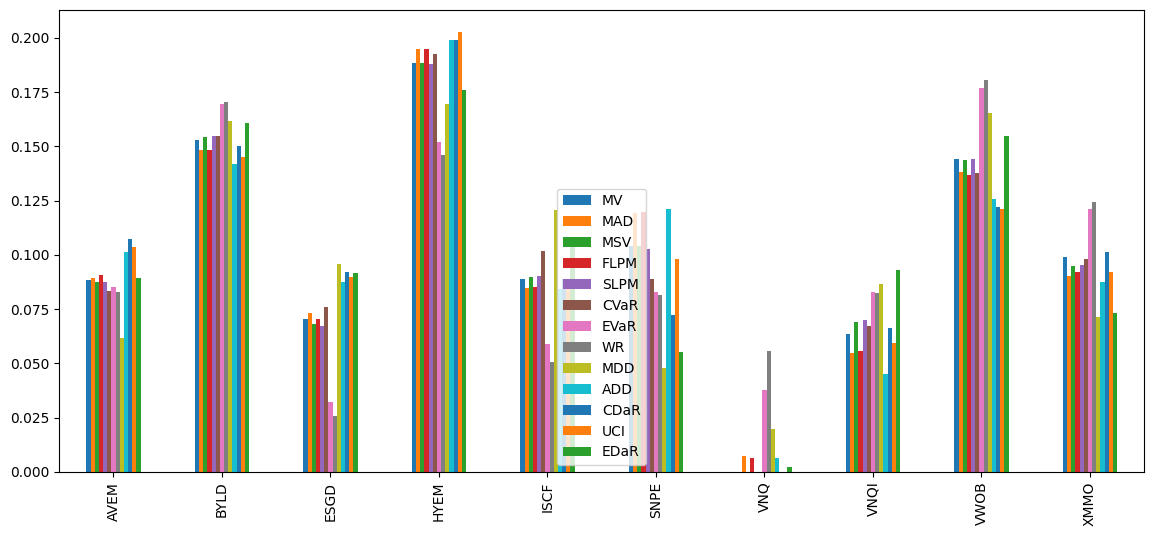

In [22]:
import matplotlib.pyplot as plt

# Plotting a comparison of assets weights for each portfolio

fig = plt.gcf()
fig.set_figwidth(14)
fig.set_figheight(6)
ax = fig.subplots(nrows=1, ncols=1)

w_s.plot.bar(ax=ax)